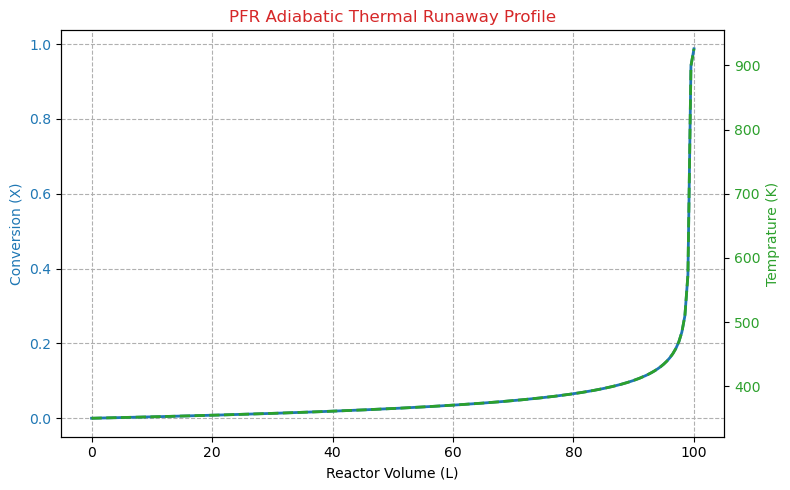

The final conversion reached for V=100L is 0.987
The final temparature reached is 926.00K


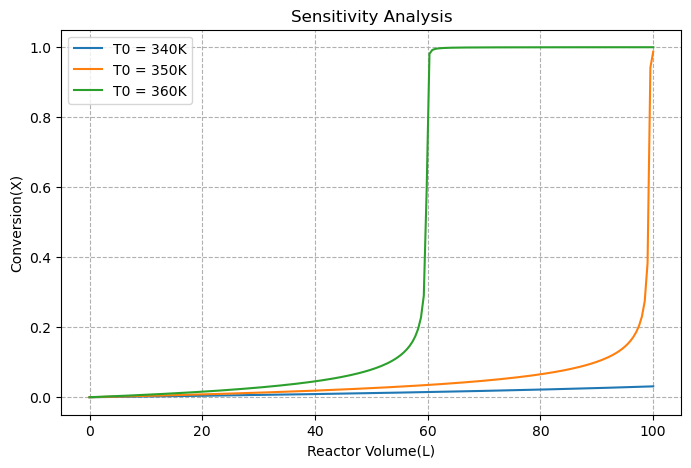

The maximum allowable feed temprature is 349.70K for which the final reactor temprature does not exceed 520K.
✗ Thermal safety limit exceeded.


In [66]:
##Mini Project-Effect of Feed Temperature on Reactor Conversion
##The aim of this project is to mathematically simulate the designing procedure of a PFR for a exothermic and irreversibe reaction, and understand whether the temprature rise could lead to thermal runaway.
##The reaction follows second-order kinetics (rA=-kCA^2) and the reactor is adiabatic
##Governing Equations: dX/dV=-rA/FA0, k=Ae^-Ea/RT and dT/dV=-ΔH*-rA/FCp
## Assumptions
#Steady-state operation
#Ideal plug flow
#Adiabatic reactor
#Constant density
#Constant heat capacity
#No pressure drop
#Single irreversible reaction
##Importing Libraries 
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
##Given Data:
FA0 = 100 #mol/min
CA0 = 2 #mol/L
T0 = 350 #K
A = 8E6 #L/mol·min
Ea = 60000 #J/mol
ΔH = -70000 #J/mol
Cp = 120 #J/mol·K
R = 8.314 #J/mol·K
V=np.linspace(0,100,200) #L
def reactor(y,V):
    X,T=y
    X = max(0.0, min(X, 1.0))
    CA=CA0*(1-X)
    k=A*np.exp(-Ea/(R*T))
    rA=-k*CA**2
    dXdV=-rA/FA0
    dTdV=(-ΔH*-rA)/(FA0*Cp)
    return [dXdV,dTdV]
initial_values=[0,350]
Ans=odeint(reactor,initial_values,V)
fig,ax1=plt.subplots(figsize=(8,5))
color1='tab:blue'
ax1.set_xlabel('Reactor Volume (L)')
ax1.set_ylabel('Conversion (X)', color=color1)
ax1.plot(V,Ans[:,0],color=color1,linewidth=2,label='Conversion')
ax1.grid(True, linestyle='--')
ax1.tick_params(axis='y',labelcolor=color1)
ax2=ax1.twinx()
color2='tab:green'
ax2.set_ylabel('Temprature (K)', color=color2)
ax2.plot(V,Ans[:,1],color=color2,linewidth=2,linestyle='--',label='Temprature')
ax2.tick_params(axis='y', labelcolor=color2)
plt.title('PFR Adiabatic Thermal Runaway Profile',color='tab:red')
fig.tight_layout()
plt.show()
#The Final temprature and the final conversion is
Final_Conv=np.max(Ans[:,0])
Final_Temp=np.max(Ans[:,1])
print(f'The final conversion reached for V=100L is {Final_Conv:.3f}')
print(f'The final temparature reached is {Final_Temp:.2f}K')
#Including a precautionary note if the temparture were to rise too much for the given operating conditions. 
Max_Allowable_Temp=520
#Sensitivity Analysis
plt.figure(figsize=(8,5))
for Temps in [340,350,360]:
    Sol=odeint(reactor,[0,Temps],V)
    plt.plot(V,Sol[:,0],label=f'T0 = {Temps}K')
plt.grid(True, linestyle='--')
plt.xlabel('Reactor Volume(L)')
plt.ylabel('Conversion(X)')
plt.title('Sensitivity Analysis')
plt.legend()
plt.show()
#Calculating the maximum feed temparture for which the final reactor temprature doesnt exceed a upper limit temprature.
Feed_Temps=np.linspace(345,350,100)
max_allowable_temp=520
max_feed_temp=[]
for T in Feed_Temps:
    IV=[0,T]
    Ans_T=odeint(reactor,IV,V)
    if np.max(Ans_T[:,1])<520:
        max_feed_temp.append(T)
print(f'The maximum allowable feed temprature is {np.max(max_feed_temp):.2f}K for which the final reactor temprature does not exceed {max_allowable_temp}K.')
if Final_Conv >= 0.90 and Final_Temp <= max_allowable_temp:
    print("✓ Reactor meets conversion and safety requirements.")
elif Final_Conv < 0.90:
    print("✗ Conversion target not achieved.")
else:
    print("✗ Thermal safety limit exceeded.")
##Engineering Recommendation
#For the given kinetics and operating conditions,the reactor does not safely achieve the desired conversion without exceeding the maximum allowable temperature of 520 K. Sensitivity analysis indicates that increasing the feed temperature increases both conversion and reactor temperature. Therefore, feed temperatures above 349.8 K are not recommended because they may result in unsafe operating conditions.
    


    

